# Stage 09 — Homework Starter Notebook

In the lecture, we learned how to create engineered features. Now it’s your turn to apply those ideas to your own project data.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Example synthetic data (replace with your project dataset)
np.random.seed(0)
n = 100
df = pd.DataFrame({
    'income': np.random.normal(60000, 15000, n).astype(int),
    'monthly_spend': np.random.normal(2000, 600, n).astype(int),
    'credit_score': np.random.normal(680, 50, n).astype(int),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n),
    'default_flag': np.random.choice([0, 1], n, p=[0.8, 0.2]),
})
df.head()

Matplotlib is building the font cache; this may take a moment.


,income,monthly_spend,credit_score,region,default_flag
0,86460,3129,661,East,0
1,66002,1191,668,North,0
2,74681,1237,734,West,0
3,93613,2581,712,South,1
4,88013,1296,712,East,1


## Engineered features — one is worked below; add at least two more

At least one of yours must encode a categorical column. `region` is the categorical
column here; the lecture shows three ways to encode it (one-hot, label, frequency).

In [3]:
from src.features import (
    add_region_frequency,
    add_spend_credit_ratio,
    add_spend_income_ratio,
)

df = add_spend_income_ratio(df)
df[['income', 'monthly_spend', 'spend_income_ratio']].head()


,income,monthly_spend,spend_income_ratio
0,86460,3129,0.036190
1,66002,1191,0.018045
2,74681,1237,0.016564
3,93613,2581,0.027571
4,88013,1296,0.014725


### Rationale for Feature 1

`spend_income_ratio` measures spending relative to available income. Stage 08 showed that both income and spending are skewed and related, so a proportional measure can separate high spending that is affordable from high spending that may indicate financial pressure.


In [4]:
df = add_spend_credit_ratio(df)
df[['monthly_spend', 'credit_score', 'spend_credit_ratio']].head()


,monthly_spend,credit_score,spend_credit_ratio
0,3129,661,4.733737
1,1191,668,1.782934
2,1237,734,1.685286
3,2581,712,3.625000
4,1296,712,1.820225


### Rationale for Feature 2

`spend_credit_ratio` combines current spending with credit quality. It may identify customers whose spending is high relative to their credit score, adding an interaction that the raw variables do not express directly.


,default_flag
spend_income_ratio,-0.036101
spend_credit_ratio,0.024831
region_frequency,0.033070
default_flag,1.000000


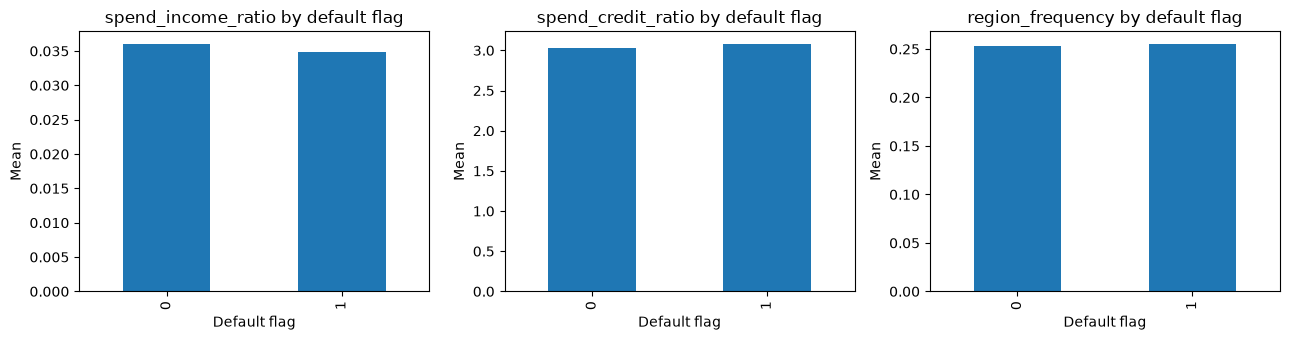

In [5]:
df = add_region_frequency(df)

engineered = [
    'spend_income_ratio',
    'spend_credit_ratio',
    'region_frequency',
]
correlations = df[engineered + ['default_flag']].corr(numeric_only=True)
display(correlations[['default_flag']].sort_values('default_flag'))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for axis, feature in zip(axes, engineered):
    df.groupby('default_flag')[feature].mean().plot(kind='bar', ax=axis)
    axis.set_title(f'{feature} by default flag')
    axis.set_xlabel('Default flag')
    axis.set_ylabel('Mean')
plt.tight_layout()
plt.show()


### Rationale for Feature 3 and Correlation Check

`region_frequency` encodes how common each region is without inventing an ordinal ranking. I chose frequency encoding instead of label encoding because North, South, East, and West have no natural order, and instead of one-hot encoding because the assignment asks for a compact engineered feature. Stage 08 showed that category balance should be checked before modeling; this feature makes that prevalence explicit.

The displayed correlations and grouped bar charts compare every engineered feature with `default_flag`. In this randomly generated sample, relationships may be weak, which is itself useful evidence: feature rationale does not guarantee predictive value, and these features should be validated on out-of-sample data.
